# Coding Project 1 : Linear Regression and Regularization

### Question 1 - Importing the Data

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import scipy.special as special
from sklearn.model_selection  import train_test_split
from statsmodels.graphics.gofplots import qqplot
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score, RepeatedKFold, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV
import statsmodels.api as sm
np.random.seed(42)

a) Import the dataset Housing.csv in Python as a pandas DataFrame. Separate the explanatory features X (Housing) from the target variable y (SalePrice).

In [54]:
data=pd.read_csv('Housing.csv', index_col=0)

In [55]:
y_data=data['SalePrice']
X_data=data.drop(columns=['SalePrice'])

In [56]:
X_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


b) Graphically determine whether the target variable SalePrice is approximately Gaussian. If not, suggest a suitable transformation to bring SalePrice closer to a Gaussian distribution and apply this transformation to the dataset. Why is it important to consider such potential transformations?

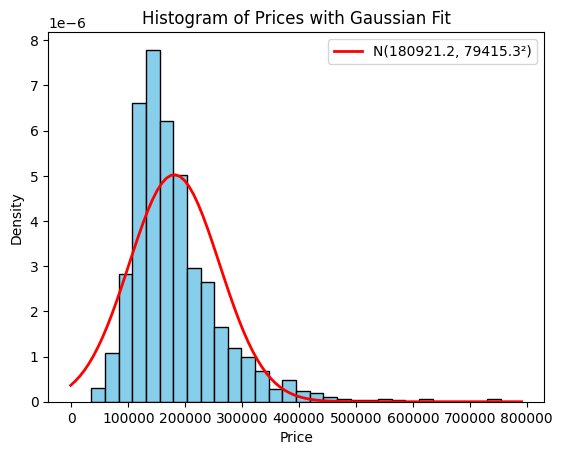

In [57]:
prices=y_data.values
mu, sigma = np.mean(prices), np.std(prices)

plt.hist(prices, bins=30, density=True,  color='skyblue', edgecolor='black')


xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, sigma)
plt.plot(x, p, 'r', linewidth=2, label=f'N({mu:.1f}, {sigma:.1f}²)')

plt.title("Histogram of Prices with Gaussian Fit")
plt.xlabel("Price")
plt.ylabel("Density")
plt.legend()
plt.show()


We see on the above plot that the prices before any transformation are skewed and clearly do not follow a gaussian distribution. Therefore, we consider below the log transform:

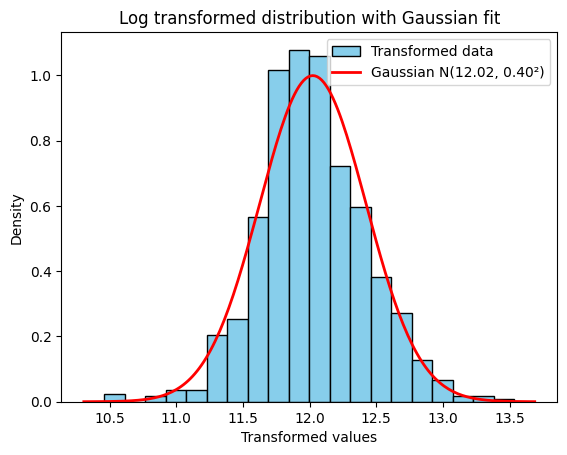

In [58]:
# log transformation
transformed=np.log(prices)

# parameters of the transformed data
mu, sigma = np.mean(transformed), np.std(transformed)


plt.hist(transformed, bins=20, density=True,
         color='skyblue', edgecolor='black', label="Transformed data")


xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
p = stats.norm.pdf(x, mu, sigma)
plt.plot(x, p, 'r', linewidth=2, label=f'Gaussian N({mu:.2f}, {sigma:.2f}²)')

plt.title("Log transformed distribution with Gaussian fit")
plt.xlabel("Transformed values")
plt.ylabel("Density")
plt.legend()
plt.show()

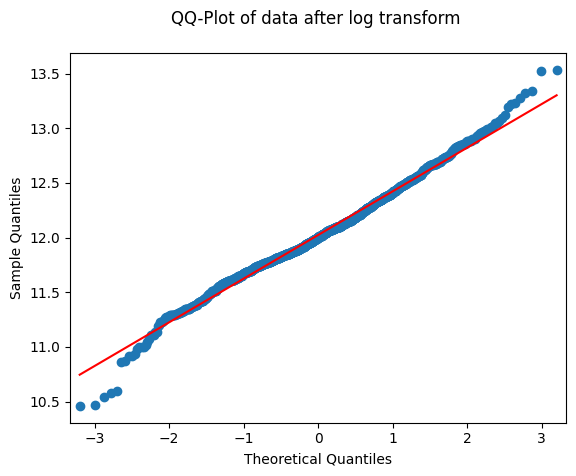

In [59]:
# We provide a QQ-plot to assess the quality of the transform
qqplot(transformed, line = 's')
plt.title("QQ-Plot of data after log transform \n")
plt.show()

We see that the log-transformed prices yield a satisfying enough QQ-plot. The tails are slightly heavier than a Gaussian but this is not a too serious issue in this case.

In [60]:
y_data=transformed

It is important to consider such transformations because many statistical and machine learning methods (Linear regression, ANOVA,...) implicitly assume the data are approximately normally distributed. If that assumption is violated, results can be biased, inefficient, or misleading.

c) Since the regression models have to be evaluated on a di erent dataset than the one used for training, split the data into two subsets: $(X,Y)_{\text{train}}$ and $(X,Y)_{\text{test}}$. Randomly assign 70% of the observations to the training set and the remaining 30% to the test set.

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3)

d) Replace missing values in $X$ using the training data statistics only: For numerical features, replace missing values with the mean of the column (computed from the training set). For categorical features, replace missing values with the most frequent category (computed from the training set). Some categorical variables admit NA (or None ) as a valid category, which should be treated as an actual level and not as missing. pd.get Next, standardize all numerical features by applying a z-score transform (subtract the training mean and divide by the training standard deviation), and apply the same transformation to the test data. Finally, use one-hot encoding for all categorical features (e.g., with dummies). After encoding, ensure that the training and test sets have exactly the same columns. Hint: After one-hot encoding, some categories may appear in the training set but not in the test set (or vice versa). You can use the command X test = X test.reindex(columns=X train.columns, fill value=0) to align the columns of the test set with those of the training set, lling missing dummy columns with zeros.

In [62]:
X_train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
136,20,RL,80.0,10400,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
1453,180,RM,35.0,3675,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal
763,60,FV,72.0,8640,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,Con,Normal
933,20,RL,84.0,11670,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,3,2007,WD,Normal
436,60,RL,43.0,10667,Pave,NaN,IR2,Lvl,AllPub,CulDSac,...,0,0,NaN,NaN,NaN,0,4,2009,ConLw,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1096,20,RL,78.0,9317,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,3,2007,WD,Normal
1131,50,RL,65.0,7804,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,12,2009,WD,Normal
1295,20,RL,60.0,8172,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Normal


In [63]:
def clean_data(X_train, X_test):
    X_train = X_train.copy()
    X_test  = X_test.copy()

    
    # We saw that the "MSSubClass" was encoded as 'categorical' in data_description.txt
    if 'MSSubClass' in X_train.columns:
        X_train['MSSubClass'] = X_train['MSSubClass'].astype('category')
    if 'MSSubClass' in X_test.columns:
        X_test['MSSubClass'] = X_test['MSSubClass'].astype('category')


    num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


    num_means = X_train[num_cols].mean()
    X_train[num_cols] = X_train[num_cols].fillna(num_means)
    X_test[num_cols]  = X_test[num_cols].fillna(num_means)


    for col in cat_cols:
        most_frequent = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(most_frequent)
        X_test[col]  = X_test[col].fillna(most_frequent)


    # we use a z-score transform in this chunk below
    means = X_train[num_cols].mean()
    stds  = X_train[num_cols].std().replace(0, 1) 
    X_train[num_cols] = (X_train[num_cols] - means) / stds
    X_test[num_cols]  = (X_test[num_cols]  - means) / stds


    X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)


    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    return X_train, X_test


In [64]:
X_train_clean, X_test_clean = clean_data(X_train, X_test)

#Checking the dimensions match
print(X_train_clean.shape[1]==X_test_clean.shape[1])

True


### Question 2 - Linear Regression on Numerical Features

2.a) Fit a linear regression model on the training dataset with numerical features only using the sklearn package.
Output a table with the name of each feature and the associated regression coefficient.

Compare the in-sample and out-of-sample Mean Squared Error (MSE) and $R^2$.
If you transformed the target variable, you have to inverse-transform the predictions before computing MSE and $R^2$, so that these metrics are reported on the original SalePrice scale. In addition, also report the MSE and $R^2$ on the transformed scale, and comment on the differences between the two. What does each set of metrics tell you about model performance?

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

num_cols = X_train_clean.select_dtypes(include=['number']).columns
X_train_num = X_train_clean[num_cols]
X_test_num = X_test_clean[num_cols]


# Model fitting
model = LinearRegression()
model.fit(X_train_num, y_train)

coefficients = pd.DataFrame({'Feature': X_train_num.columns,
    'Coefficient': model.coef_})


y_train_pred = model.predict(X_train_num)

y_test_pred = model.predict(X_test_num)
y_train_inv = np.exp(y_train_pred)
y_test_inv = np.exp(y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
mse_train_inv = mean_squared_error(np.exp(y_train), y_train_inv)
mse_test_inv = mean_squared_error(np.exp(y_test), y_test_inv)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
r2_train_inv = r2_score(np.exp(y_train), y_train_inv)
r2_test_inv = r2_score(np.exp(y_test), y_test_inv)

print(f"In-sample MSE (transformed): {mse_train:.4f}, R^2: {r2_train:.4f}")
print(f"Out-of-sample MSE (transformed): {mse_test:.4f}, R^2: {r2_test:.4f}")
print(f"In-sample MSE (original): {mse_train_inv:.4f}, R^2: {r2_train_inv:.4f}")
print(f"Out-of-sample MSE (original): {mse_test_inv:.4f}, R^2: {r2_test_inv:.4f}")


In-sample MSE (transformed): 0.0220, R^2: 0.8581
Out-of-sample MSE (transformed): 0.0219, R^2: 0.8711
In-sample MSE (original): 1433793965.6864, R^2: 0.7618
Out-of-sample MSE (original): 829114329.1345, R^2: 0.8812


Comments: For both transformed and original data, we obtain similar values for the in-sample and out-sample MSE's and $R^2$ values. Hence we claim that the model does not overfit the training data. 

The MSE measures how far the model's predictions are from the actual values, while the $R^2$ tells us how well the model explains the variance in the target variable.

In our case, the MSE is relatively low and the $R^2$ is somewhat close to 1, which shows satisfying performance for the model.

In [66]:
print(np.round(model.intercept_,4)) #beta_0

12.0289


In [67]:
print(coefficients)


          Feature  Coefficient
0     LotFrontage    -0.001184
1         LotArea     0.021460
2     OverallQual     0.114339
3     OverallCond     0.047950
4       YearBuilt     0.091427
5    YearRemodAdd     0.027565
6      MasVnrArea    -0.006483
7      BsmtFinSF1     0.009727
8      BsmtFinSF2     0.001544
9       BsmtUnfSF     0.002211
10    TotalBsmtSF     0.012726
11       1stFlrSF     0.039123
12       2ndFlrSF     0.019685
13   LowQualFinSF     0.005419
14      GrLivArea     0.045547
15   BsmtFullBath     0.034196
16   BsmtHalfBath     0.003012
17       FullBath     0.016306
18       HalfBath     0.011662
19   BedroomAbvGr     0.006731
20   KitchenAbvGr    -0.024333
21   TotRmsAbvGrd     0.030204
22     Fireplaces     0.033572
23    GarageYrBlt    -0.011872
24     GarageCars     0.059927
25     GarageArea     0.011736
26     WoodDeckSF     0.015838
27    OpenPorchSF    -0.004768
28  EnclosedPorch     0.012229
29      3SsnPorch     0.010653
30    ScreenPorch     0.021197
31      

b) The $\texttt{sklearn}$ package does not provide standard errors for the estimated regression coecients, which are essential tools to assess the statistical precision of an estimate. Therefore, you will now use matrix algebra in Python with the $\texttt{numpy}$ package to compute the standard errors of the estimated coefficients $\hat\beta$ . All computations in this part should be performed using the training set only. Let $A\in\mathbb{R}^{m\times (d+1)}$ denote the design matrix (including a column of ones for the intercept term), and let $y\in\mathbb{R}^m$ denote the observed target values.

(i) Compute the estimated coefficients $\hat{\beta}$ using:

$$
\hat{\beta} = (A^{\top}A)^{-1}A^{\top}y
$$

the estimate of the intercept.  
In code, do not form matrix inverses explicitly; instead use a numerically stable equivalent such as  
np.linalg.solve(A.T @ A, A.T @ y).


In [68]:
A=np.hstack((np.ones((X_train_num.shape[0], 1)), X_train_num.values))

beta_hat=np.linalg.solve(A.T @ A, A.T @ y_train)

# printing the values of the coefficients
print(np.round(beta_hat,5))

[ 1.202889e+01 -1.180000e-03  2.146000e-02  1.143400e-01  4.795000e-02
  9.143000e-02  2.756000e-02 -6.480000e-03 -1.533000e-02 -6.690000e-03
 -2.208000e-02  3.709000e-02  1.275100e-01  1.197800e-01  1.630000e-02
 -7.493000e-02  3.420000e-02  3.010000e-03  1.631000e-02  1.166000e-02
  6.730000e-03 -2.433000e-02  3.020000e-02  3.357000e-02 -1.187000e-02
  5.993000e-02  1.174000e-02  1.584000e-02 -4.770000e-03  1.223000e-02
  1.065000e-02  2.120000e-02 -2.068000e-02 -4.050000e-03  5.630000e-03
 -4.120000e-03]


(ii) Compute the standard error of each coefficients $\hat{\beta}_j$ using:

$$\hat{\sigma}^2 = \frac{1}{m - (d+1)}\sum_{i=1}^m (y_i - \hat{y}_i)^2
$$


$$\mathrm{Var}(\hat{\boldsymbol{\beta}}) = \hat{\sigma}^2 (\mathbf{A}^\mathsf{T}\mathbf{A})^{-1},
$$

and

$$
\mathrm{SE}(\hat{\beta}_j) = \sqrt{\hat{\sigma}^2 \cdot \left[ (\mathbf{A}^\mathsf{T}\mathbf{A})^{-1} \right]_{jj}},
$$

where $\left[ (\mathbf{A}^\mathsf{T}\mathbf{A})^{-1} \right]_{jj}$ denotes the $j$-th diagonal element.

In [69]:
y_train_pred_np = A @ beta_hat
residuals = y_train - y_train_pred_np
m = X_train_num.shape[0]
d = X_train_num.shape[1]
sigma_squared = (1 / (m - (d + 1))) * np.sum(residuals**2)
cov_matrix = sigma_squared * np.linalg.inv(A.T @ A)
standard_errors = np.sqrt(np.diag(cov_matrix))
print("Standard Errors:", standard_errors)


Standard Errors: [4.72312952e-03 5.66754226e-03 5.31765977e-03 8.46220904e-03
 5.95742494e-03 1.08429653e-02 7.46802024e-03 5.63317048e-03
 1.14945303e+05 3.77870207e+04 1.11455084e+05 1.11809664e+05
            nan            nan            nan            nan
 7.02574194e-03 5.16496471e-03 8.02664242e-03 6.85355147e-03
 7.39594343e-03 5.64339751e-03 1.06508129e-02 5.95880124e-03
 8.58841525e-03 1.09875576e-02 1.10297032e-02 5.25853632e-03
 5.19115820e-03 5.43539048e-03 4.79485521e-03 5.04886772e-03
 5.20536701e-03 4.90240361e-03 4.86253417e-03 4.87221327e-03]


/tmp/ipykernel_219881/148991961.py:7: RuntimeWarning: invalid value encountered in sqrt
  standard_errors = np.sqrt(np.diag(cov_matrix))


(iii) Compute the in-sample MSE and R2 using matrix algebra. (À CHANGER ICI)

In [70]:
#Computing R^2 in the transformed data unit
mse_np = np.mean(residuals**2)
ss_total = np.sum((y_train - np.mean(y_train))**2)
r2_np = 1 - (np.sum(residuals**2) / ss_total)
print(f"In-sample MSE (transform): {mse_np:.4f}, R^2: {r2_np:.4f}")

#Computing R^2 in the original prices unit
y_train_inv_np = np.exp(y_train)
y_train_pred_inv_np = np.exp(y_train_pred_np)
residuals_inv = y_train_inv_np - y_train_pred_inv_np
mse_inv_np = np.mean(residuals_inv**2)
ss_total_inv = np.sum((y_train_inv_np - np.mean(y_train_inv_np))**2)
r2_inv_np = 1 - (np.sum(residuals_inv**2) / ss_total_inv)

print(f"In-sample MSE (original): {mse_inv_np:.4f}, R^2: {r2_inv_np:.4f}")

In-sample MSE (transform): 0.0220, R^2: 0.8581
In-sample MSE (original): 1433793965.6863, R^2: 0.7618


We obtain similar $R^2$ and MSE values as we did earlier.

iv) Replace $(A^TA)^{-1}A^T$ by the Moore–Penrose pseudoinverse $A^{\dagger}$ (use np.linalg.pinv).
Do $\hat{\beta}$'s , $\sigma^2$
, and the standard errors change? Briefly explain when the results are identical
and when they can differ

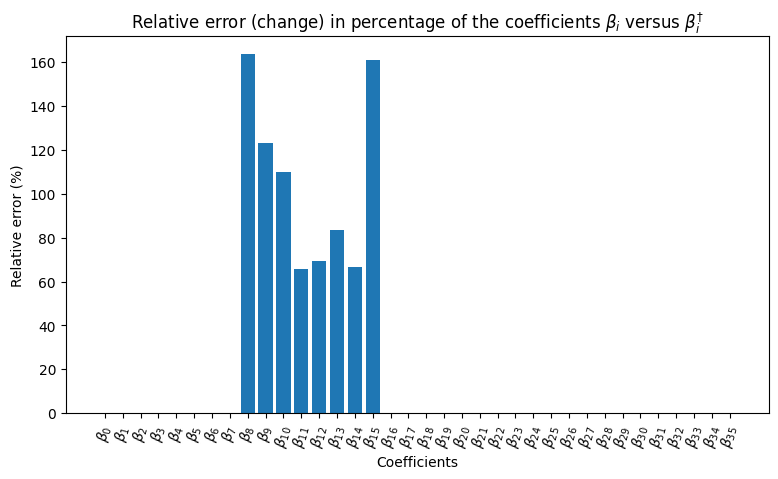

In [71]:
# Computing the coefficients beta_hat using the pseudo-inverse matrix of A
beta_hat_pinv = np.linalg.pinv(A) @ y_train

plt.figure(figsize=(10/1.3,6/1.3))
plt.bar([r"$\beta_{" + str(i) +"}$" for i in range(36)],100*np.abs(beta_hat-beta_hat_pinv)/np.abs(beta_hat))
plt.title(r"Relative error (change) in percentage of the coefficients $\beta_i$ versus $\beta^{\dagger}_{i}$")
plt.tight_layout()
plt.xlabel("Coefficients")
plt.xticks(rotation=75)
plt.ylabel("Relative error (%)")
plt.show()

The values of $\beta_j^{\dagger}$ and $\beta_j$ are not always the same for all $j$'s. This is the case because the use of the Moore-Penrose pseudo-inverse matrix picks the vector $\beta$ that has the smallest euclidean norm in the set of solutions to the normal equations 

The value of $\hat{\sigma}$ is however unchanged whether we use the Moore-Penrose pseudo-inverse matrix of $A$ or not. The reason for this is that the predicted values will take on the same values even if the $\beta$ coefficients are not the same after using the Moore-Penrose inverse. Indeed, the parameters vectors $\beta^{\dagger}$ and $\beta$ are both solutions to the normal equations, so they both yield the same output.

The standard errors of the $\beta$'s are not the same as the standard errors of the $\beta_j^{\dagger}$ (see below). Indeed, the product $$\hat{\sigma}^2(A^TA)^{-1}$$ is not equal to the product $$\hat{\sigma}^2(A^{\dagger}(A^{\dagger})^T)$$ where this last product gives us the covariance matrix of the $\beta$ coefficents using the pseudo-inverse matrix. These products are the same if the design matrix $A$ has full rank.

In [72]:
#We compute the variances of the coefficients using the PINV matrix
standard_errors_betas_pinv = np.sqrt(np.diag(sigma_squared * np.linalg.pinv(A.T @ A)))
print(standard_errors_betas_pinv)


[0.00472313 0.00566754 0.00531766 0.00846221 0.00595742 0.01084297
 0.00746802 0.00563317 0.00530347 0.00489371 0.00470741 0.00658321
 0.00782458 0.00656779 0.00504174 0.00712096 0.00702574 0.00516496
 0.00802664 0.00685355 0.00739594 0.0056434  0.01065081 0.0059588
 0.00858842 0.01098756 0.0110297  0.00525854 0.00519116 0.00543539
 0.00479486 0.00504887 0.00520537 0.0049024  0.00486253 0.00487221]


(v) Confirm your results using the OLS function from the $\texttt{statsmodels}$ package. Report
the coefficient table and standard errors, and check that they match your matrix-algebra
results up to numerical rounding.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     181.0
Date:                Tue, 14 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:29:09   Log-Likelihood:                 500.29
No. Observations:                1022   AIC:                            -932.6
Df Residuals:                     988   BIC:                            -765.0
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.0289      0.005   2549.387      0.0

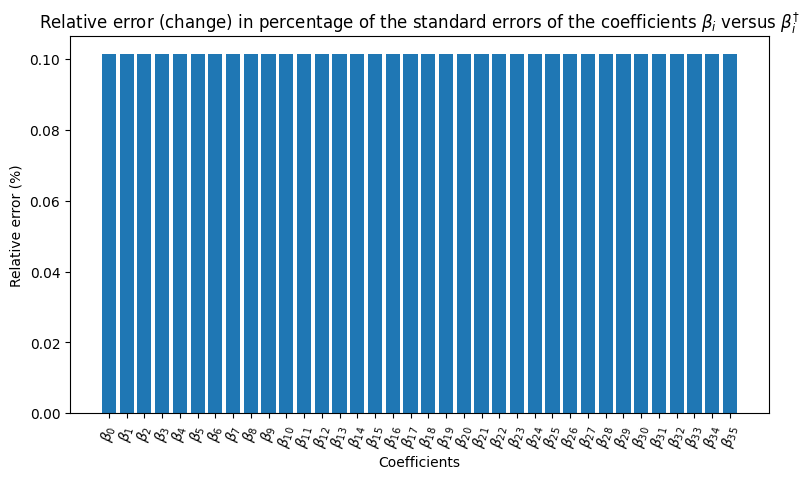

In [73]:
linear_model = sm.OLS(y_train, A)
results = linear_model.fit()
print(results.summary())


plt.figure(figsize=(10/1.3,6/1.3))
plt.bar([r"$\beta_{" + str(i) +"}$" for i in range(36)],100*np.abs(standard_errors_betas_pinv-results.bse)/np.abs(results.bse))
plt.title(r"Relative error (change) in percentage of the standard errors of the coefficients $\beta_i$ versus $\beta^{\dagger}_{i}$")
plt.tight_layout()
plt.xlabel("Coefficients")
plt.xticks(rotation=75)
plt.ylabel("Relative error (%)")
plt.show()

Indeed, the standard errors we obtained using the pseudo-inverse matrix yield the same up to numerical rounding (about 0.1% of relative error for all values). Notice that the s

### Question 3 - Regularization Techniques

### 3.a) Linear regression with the full Housing dataset (numerical + categorical).
#How do the in-sample and out-of-sample metrics change when including categorical features, and what does this reveal about the model’s ability to generalize?


In [74]:
X_train=X_train_clean
X_test=X_test_clean

In [75]:
model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.DataFrame({'Feature': X_train.columns,
    'Coefficient': model.coef_})


y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_inv = np.exp(y_train_pred)
y_test_inv = np.exp(y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

mse_train_inv = mean_squared_error(np.exp(y_train), y_train_inv)
mse_test_inv = mean_squared_error(np.exp(y_test), y_test_inv)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

r2_train_inv = r2_score(np.exp(y_train), y_train_inv)
r2_test_inv = r2_score(np.exp(y_test), y_test_inv)

print(f"In-sample MSE (transformed): {mse_train:.4f}, R^2: {r2_train:.4f}")
print(f"Out-of-sample MSE (transformed): {mse_test:.4f}, R^2: {r2_test:.4f}")
print(f"In-sample MSE (original): {mse_train_inv:.4f}, R^2: {r2_train_inv:.4f}")
print(f"Out-of-sample MSE (original): {mse_test_inv:.4f}, R^2: {r2_test_inv:.4f}")


In-sample MSE (transformed): 0.0078, R^2: 0.9495
Out-of-sample MSE (transformed): 7.8765, R^2: -45.4293
In-sample MSE (original): 295666950.6187, R^2: 0.9509
Out-of-sample MSE (original): 33251794889.9716, R^2: -3.7652


The model performs very well on the training data (high R²), but its performance drops dramatically on the test data (negative R²), which indicates severe overfitting, the model has learned the noise and specific patterns (especially added by the categorical features) of the training set instead of the underlying relationships.

b) Implement the Truncated Pseudoinverse, Ridge, Lasso, and Elastic Net regressions. Use 8-fold cross-validation on the training set to tune the hyperparameters of each regularization technique, using the MSE as the selection criterion. Compare their in-sample and out-ofsample performance (MSE and R2) with the OLS results from Questions 2.a) and 3.a). All regressions should include an intercept term. The intercept must not be penalized during regularization. Why is it important that the intercept is not penalized in these models?

In [76]:
def evaluate_metrics_with_inverse_log(y_train, y_train_pred, y_test, y_test_pred):
    mse_tr = mean_squared_error(y_train, y_train_pred)
    mse_te = mean_squared_error(y_test, y_test_pred)
    r2_tr  = r2_score(y_train, y_train_pred)
    r2_te  = r2_score(y_test, y_test_pred)

    # inverse log transformation to get back to original scale
    y_train_orig     = np.exp(y_train)
    y_test_orig      = np.exp(y_test)
    y_train_pred_org = np.exp(y_train_pred)
    y_test_pred_org  = np.exp(y_test_pred)

    mse_tr_org = mean_squared_error(y_train_orig, y_train_pred_org)
    mse_te_org = mean_squared_error(y_test_orig,  y_test_pred_org)
    r2_tr_org  = r2_score(y_train_orig, y_train_pred_org)
    r2_te_org  = r2_score(y_test_orig,  y_test_pred_org)

    return {
        "Train MSE (transf.)": mse_tr,
        "Test MSE (transf.)":  mse_te,
        "Train R2 (transf.)":  r2_tr,
        "Test R2 (transf.)":   r2_te,
        "Train MSE (orig.)":   mse_tr_org,
        "Test MSE (orig.)":    mse_te_org,
        "Train R2 (orig.)":    r2_tr_org,
        "Test R2 (orig.)":     r2_te_org,
    }


In [77]:
ols = LinearRegression(fit_intercept=True)
ols.fit(X_train, y_train)

y_tr_pred = ols.predict(X_train)
y_te_pred = ols.predict(X_test)

ols_scores = evaluate_metrics_with_inverse_log(y_train, y_tr_pred, y_test, y_te_pred)
print("OLS:", ols_scores)


OLS: {'Train MSE (transf.)': 0.007832517054420307, 'Test MSE (transf.)': 7.876548953134668, 'Train R2 (transf.)': 0.949469472921211, 'Test R2 (transf.)': -45.42927798233622, 'Train MSE (orig.)': 295666950.61874515, 'Test MSE (orig.)': 33251794889.97157, 'Train R2 (orig.)': 0.9508742638195504, 'Test R2 (orig.)': -3.765168831078536}


### TRUNCATED PSEUDO-INVERSE

In [78]:
def _tpi_fit(X, y, n_components):
    #we substract the mean to have the intercept not penalized
    X_mean = X.mean(axis=0)
    y_mean = y.mean()
    Xc = X - X_mean
    yc = y - y_mean

    U, s, VT = np.linalg.svd(Xc, full_matrices=False)

    r = int(n_components)
    #we keep only the first r components with biggest singular values
    Ur  = U[:, :r]
    sr  = s[:r]
    VTr = VT[:r, :]

    coef = VTr.T @ (Ur.T @ yc / sr)
    intercept = (y_mean - (X_mean @ coef).item()) 
    return coef, intercept

def _tpi_predict(X, coef, intercept):
    X = np.asarray(X, dtype=float)
    return X @ coef + intercept

def tpi_cv_best_n(X, y, n_splits=8, random_state=42):
    p = X.shape[1]

    n_grid = np.unique(np.linspace(1, p, 10, dtype=int)).tolist()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    best_n, best_mse = None, np.inf

    for n in n_grid:
        fold_mse = []
        for tr_idx, va_idx in kf.split(X):
            Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
            ytr, yva = y[tr_idx], y[va_idx]

            coef, intercept = _tpi_fit(Xtr, ytr, n_components=n)
            yhat = _tpi_predict(Xva, coef, intercept)
            fold_mse.append(mean_squared_error(yva, yhat))

        avg_mse = np.mean(fold_mse)
        if avg_mse < best_mse:
            best_mse = avg_mse
            best_n = n

    return best_n, best_mse

def tpi_fit_predict_full(X_train, y_train, X_test, best_n):

    coef, intercept = _tpi_fit(X_train, y_train, n_components=best_n)
    ytr_hat = _tpi_predict(X_train, coef, intercept)
    yte_hat = _tpi_predict(X_test, coef, intercept)
    return ytr_hat, yte_hat, {"n_components": best_n}


In [79]:
best_n, cv_mse_tpi = tpi_cv_best_n(X_train, y_train, n_splits=8)
y_tr_tpi, y_te_tpi, tpi_params = tpi_fit_predict_full(X_train, y_train, X_test, best_n=best_n)

tpi_scores = evaluate_metrics_with_inverse_log(y_train, y_tr_tpi, y_test, y_te_tpi)
print("TPI best_n:", best_n, " | CV MSE (transf.):", cv_mse_tpi)
print("TPI:", tpi_scores)


TPI best_n: 140  | CV MSE (transf.): 0.02420768848509753
TPI: {'Train MSE (transf.)': 0.013185491511875523, 'Test MSE (transf.)': 0.02086913423237607, 'Train R2 (transf.)': 0.914935412044592, 'Test R2 (transf.)': 0.8769843442488776, 'Train MSE (orig.)': 617740462.5459214, 'Test MSE (orig.)': 669089840.7711898, 'Train R2 (orig.)': 0.8973610174302117, 'Test R2 (orig.)': 0.9041156705981083}


### RIDGE REGRESSION    

In [80]:
#ridge
ridge = Ridge(fit_intercept=True, random_state=42)

ridge_grid = {"alpha": np.logspace(-4, 4, 21)}  

ridge_cv = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_grid,
    cv=KFold(n_splits=8, shuffle=True, random_state=42),
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    refit=True
)

ridge_cv.fit(X_train, y_train)

y_tr_ridge = ridge_cv.best_estimator_.predict(X_train)
y_te_ridge = ridge_cv.best_estimator_.predict(X_test)

ridge_scores = evaluate_metrics_with_inverse_log(y_train, y_tr_ridge, y_test, y_te_ridge)
print("Ridge best_params:", ridge_cv.best_params_, " | CV MSE (transf.):", -ridge_cv.best_score_)
print("Ridge:", ridge_scores)

Ridge best_params: {'alpha': np.float64(15.848931924611142)}  | CV MSE (transf.): 0.023116784623793796
Ridge: {'Train MSE (transf.)': 0.012984270632031551, 'Test MSE (transf.)': 0.019424035277017897, 'Train R2 (transf.)': 0.9162335639729092, 'Test R2 (transf.)': 0.8855026562037099, 'Train MSE (orig.)': 649091297.7337662, 'Test MSE (orig.)': 722737462.4123875, 'Train R2 (orig.)': 0.8921520048731715, 'Test R2 (orig.)': 0.8964276653234448}


### LASSO REGRESSION

In [81]:
#Lasso
lasso = Lasso(fit_intercept=True, random_state=42)

lasso_grid = {"alpha": np.logspace(-4, 1, 21)}

lasso_cv = GridSearchCV(
    lasso, lasso_grid,
    cv=KFold(n_splits=8, shuffle=True, random_state=42),
    scoring="neg_mean_squared_error", n_jobs=-1, refit=True
)
lasso_cv.fit(X_train, y_train)

y_tr_lasso = lasso_cv.best_estimator_.predict(X_train)
y_te_lasso = lasso_cv.best_estimator_.predict(X_test)

lasso_scores = evaluate_metrics_with_inverse_log(y_train, y_tr_lasso, y_test, y_te_lasso)
print("Lasso best_params:", lasso_cv.best_params_, " | CV MSE (transf.):", -lasso_cv.best_score_)
print("Lasso:", lasso_scores)


Lasso best_params: {'alpha': np.float64(0.0017782794100389228)}  | CV MSE (transf.): 0.023829356631733273
Lasso: {'Train MSE (transf.)': 0.016959924387037403, 'Test MSE (transf.)': 0.018654041638519338, 'Train R2 (transf.)': 0.890585119376183, 'Test R2 (transf.)': 0.8900414775706809, 'Train MSE (orig.)': 995983384.947531, 'Test MSE (orig.)': 708552167.3229032, 'Train R2 (orig.)': 0.8345150957634913, 'Test R2 (orig.)': 0.8984604977237327}


### ELASTIC NET

In [82]:
#Elastic Net
enet =  ElasticNet(fit_intercept=True, random_state=42)
enet_grid = {
    "alpha": np.logspace(-4, 1, 13),
    "l1_ratio": np.linspace(0.05, 0.95, 10)
}

enet_cv = GridSearchCV(
    enet, enet_grid,
    cv=KFold(n_splits=8, shuffle=True, random_state=42),
    scoring="neg_mean_squared_error", n_jobs=-1, refit=True
)
enet_cv.fit(X_train, y_train)

y_tr_enet = enet_cv.best_estimator_.predict(X_train)
y_te_enet = enet_cv.best_estimator_.predict(X_test)

enet_scores = evaluate_metrics_with_inverse_log(y_train, y_tr_enet, y_test, y_te_enet)
print("Elastic Net best_params:", enet_cv.best_params_, " | CV MSE (transf.):", -enet_cv.best_score_)
print("Elastic Net:", enet_scores)


/home/celestin/g/eth/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.337e+00, tolerance: 1.338e-02
  model = cd_fast.enet_coordinate_descent(
/home/celestin/g/eth/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.555e-01, tolerance: 1.338e-02
  model = cd_fast.enet_coordinate_descent(
/home/celestin/g/eth/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularis

Elastic Net best_params: {'alpha': np.float64(0.004641588833612782), 'l1_ratio': np.float64(0.15)}  | CV MSE (transf.): 0.023087252585279466
Elastic Net: {'Train MSE (transf.)': 0.014345899987373309, 'Test MSE (transf.)': 0.017741693160720797, 'Train R2 (transf.)': 0.9074491785022717, 'Test R2 (transf.)': 0.8954194268914442, 'Train MSE (orig.)': 745990511.9643128, 'Test MSE (orig.)': 639414689.8981123, 'Train R2 (orig.)': 0.8760519800837221, 'Test R2 (orig.)': 0.9083682862679044}


In [83]:
summary = pd.DataFrame([
    {"Model": "OLS",                    **ols_scores, "Best Params": "-",
     "CV MSE (transf.)": np.nan},
    {"Model": "Truncated Pseudoinverse", **tpi_scores, "Best Params": tpi_params,
     "CV MSE (transf.)": cv_mse_tpi},
    {"Model": "Ridge",                  **ridge_scores, "Best Params": ridge_cv.best_params_,
     "CV MSE (transf.)": -ridge_cv.best_score_},
    {"Model": "Lasso",                  **lasso_scores, "Best Params": lasso_cv.best_params_,
     "CV MSE (transf.)": -lasso_cv.best_score_},
    {"Model": "Elastic Net",            **enet_scores, "Best Params": enet_cv.best_params_,
     "CV MSE (transf.)": -enet_cv.best_score_},
])

cols_order = ["Model", "Best Params", "CV MSE (transf.)",
              "Train MSE (transf.)", "Test MSE (transf.)", "Train R2 (transf.)", "Test R2 (transf.)",
              "Train MSE (orig.)", "Test MSE (orig.)", "Train R2 (orig.)", "Test R2 (orig.)"]
summary = summary[cols_order]


summary = summary.sort_values(by="Test MSE (orig.)", ascending=True, na_position="last")
summary.reset_index(drop=True, inplace=True)

summary


,Model,Best Params,CV MSE (transf.),Train MSE (transf.),Test MSE (transf.),Train R2 (transf.),Test R2 (transf.),Train MSE (orig.),Test MSE (orig.),Train R2 (orig.),Test R2 (orig.)
0,Elastic Net,"{'alpha': 0.004641588833612782, 'l1_ratio': 0.15}",0.023087,0.014346,0.017742,0.907449,0.895419,7.459905e+08,6.394147e+08,0.876052,0.908368
1,Truncated Pseudoinverse,{'n_components': 140},0.024208,0.013185,0.020869,0.914935,0.876984,6.177405e+08,6.690898e+08,0.897361,0.904116
2,Lasso,{'alpha': 0.0017782794100389228},0.023829,0.016960,0.018654,0.890585,0.890041,9.959834e+08,7.085522e+08,0.834515,0.898460
3,Ridge,{'alpha': 15.848931924611142},0.023117,0.012984,0.019424,0.916234,0.885503,6.490913e+08,7.227375e+08,0.892152,0.896428
4,OLS,-,NaN,0.007833,7.876549,0.949469,-45.429278,2.956670e+08,3.325179e+10,0.950874,-3.765169


Compared to the OLS model, all regularized methods achieved much better generalization performance. While OLS severely overfitted the training data (high training R² but strongly negative test R²), the regularized models significantly reduced overfitting, yielding test R² values around 0.90 and much lower MSE on both transformed and original scales. Among them, the Elastic Net provided the best overall trade-off between bias and variance, combining the stability of Ridge with the sparsity of Lasso. Importantly, the intercept term was not penalized during regularization to avoid biasing the model’s baseline level. Penalizing the intercept would artificially pull predictions toward zero, especially when the target variable has a non-zero mean, thereby distorting the model’s calibration and degrading its overall fit.

c) During cross-validation, what are possible sources of information leakage? Briefly describe what leakage means in this context, and explain what steps you would take to avoid it if you were building a more complete data preprocessing pipeline (e.g., with imputation, scaling, or encoding). You do not need to implement these steps here, only to explain the idea.

In the context of cross-validation, information leakage occurs when data from the validation folds are inadvertently used directly or indirectly during model training, giving the model access to information it should not have at that stage. This leads to overly optimistic performance estimates that will not generalize to unseen data. Leakage can happen in many subtle ways, for example if data preprocessing steps such as scaling, imputation, or encoding are applied to the entire dataset before cross-validation, allowing statistics (e.g., means, standard deviations, category frequencies) computed from the validation folds to influence the training folds. To avoid this, all preprocessing steps must be performed inside the cross-validation loop, using parameters learned only from the training fold and then applied to the corresponding validation fold. In a complete pipeline, this is typically achieved by combining preprocessing and modeling steps within a scikit-learn Pipeline, which ensures that data transformations are fit exclusively on the training data in each fold, thus fully preventing leakage.

d) For the Lasso and Elastic Net regularization techniques, how many coefficients are non-zero (i.e. $\hat{\beta_{j}}\neq0$)? Compare this number with the number of coefficients retained by the Ridge and Truncated Pseudoinverse models and provide an explanation.

In [84]:
#count "non-zero" with a small tolerance (robust to float noise)
def nnz(coefs, tol=1e-8):
    coefs = np.asarray(coefs, dtype=float).ravel()
    return int(np.sum(np.abs(coefs) > tol))

lasso_coef = lasso_cv.best_estimator_.coef_
enet_coef  = enet_cv.best_estimator_.coef_
ridge_coef = ridge_cv.best_estimator_.coef_

lasso_nnz = nnz(lasso_coef)
enet_nnz  = nnz(enet_coef)
ridge_nnz = nnz(ridge_coef)  


Xtr = np.asarray(X_train, dtype=float)
ytr = np.asarray(y_train, dtype=float).ravel()
tpi_coef, tpi_intercept = _tpi_fit(Xtr, ytr, n_components=best_n)


tpi_nnz = nnz(tpi_coef)  

p = Xtr.shape[1]

print(f"Lasso:        non-zero coefficients = {lasso_nnz} / {p}")
print(f"Elastic Net:  non-zero coefficients = {enet_nnz} / {p}")
print(f"Ridge:        non-zero coefficients = {ridge_nnz} / {p}  (L2 shrinks but rarely exactly zero)")
print(f"TPI:          effective components kept = {best_n}  (hard truncation in SVD-space)")
print(f"TPI (coef):   'non-zero' coefficients in original basis = {tpi_nnz} / {p} "
      f"(not sparse by design; truncation acts in component space)")





Lasso:        non-zero coefficients = 65 / 252
Elastic Net:  non-zero coefficients = 106 / 252
Ridge:        non-zero coefficients = 252 / 252  (L2 shrinks but rarely exactly zero)
TPI:          effective components kept = 140  (hard truncation in SVD-space)
TPI (coef):   'non-zero' coefficients in original basis = 252 / 252 (not sparse by design; truncation acts in component space)


The results show important differences in how each regularization technique handles coefficient sparsity and model complexity. The Lasso retained only 65 out of 252 coefficients, confirming its strong ability to perform feature selection by setting many coefficients exactly to zero through the L1 penalty. The Elastic Net, which combines L1 and L2 regularization, kept 106 coefficients, producing a less sparse but more stable solution. In contrast, the Ridge regression retained all coefficients, as the L2 penalty continuously shrinks coefficients but never drives them exactly to zero. The Truncated Pseudoinverse (TPI) kept 140 effective components in the SVD space, but all 252 coefficients remained non-zero in the original feature space since truncation occurs on singular vectors rather than individual variables. Overall, Lasso and Elastic Net achieve sparsity and interpretability, whereas Ridge and TPI control model complexity through smooth shrinkage or dimensionality reduction rather than zeroing out features.

e) Based on your finndings from Questions 2 and 3, which model would you recommend for predicting house prices? Justify your choice not only by comparing performance metrics, but also by discussing the nature of the problem (e.g., number of features, presence of categorical variables, potential collinearity, sparsity, nonlinearity). Explain how the strengths and limitations of the chosen method align with this problem structure.

Based on the results, we would recommend using the Elastic Net model for predicting house prices. It achieved the best overall balance between bias and variance, with the highest test $R^2$ and the lowest out-of-sample MSE among all models. Compared to OLS, which clearly overfit (with all data) or was less accurate (with only numerical features), and Ridge, which retained all coefficients, Elastic Net provided a more robust and interpretable model while maintaining strong predictive accuracy. Conceptually, this choice aligns well with the structure of the housing price prediction problem: the dataset contains a relatively large number of features (including both numerical and one-hot encoded categorical variables), which are often correlated and potentially redundant. The Elastic Net’s combination of L1 and L2 penalties is particularly effective in such contexts : it can select informative variables like Lasso while stabilizing coefficients among correlated predictors like Ridge.